In [10]:
from crack_seg.config import *
from PIL import Image
import matplotlib.pyplot as plt
from crack_seg.data_handlers.dataset import CrackDataset
from crack_seg.predict import predict
import importlib
import numpy as np
from crack_seg.data_handlers.transforms import val_transform 
from crack_seg.utils.visualization import display_prediction

In [11]:
list(DATA_ROOT.iterdir())

[WindowsPath('CConCrack/data_split.py'),
 WindowsPath('CConCrack/info.txt'),
 WindowsPath('CConCrack/Test'),
 WindowsPath('CConCrack/Train'),
 WindowsPath('CConCrack/Validation')]

In [12]:
# print(type(TRAIN_IMG_DIR), TRAIN_IMG_DIR)

# img_path = list(TRAIN_IMG_DIR.iterdir())[0]
# print(img_path)

# img = Image.open(img_path)
# plt.imshow(img)
# plt.axis("off")  # Hide axes for better visualization
# plt.show()    

In [13]:
import crack_seg.models.unet as unet
model = unet.get_model().to(DEVICE)
# 2. Load the state dictionary
checkpoint_path = Path(CHECKPOINT_DIR) / f"unet_best.pth"
state_dict = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(state_dict)
# 3. Set model to evaluation mode (important for inference)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

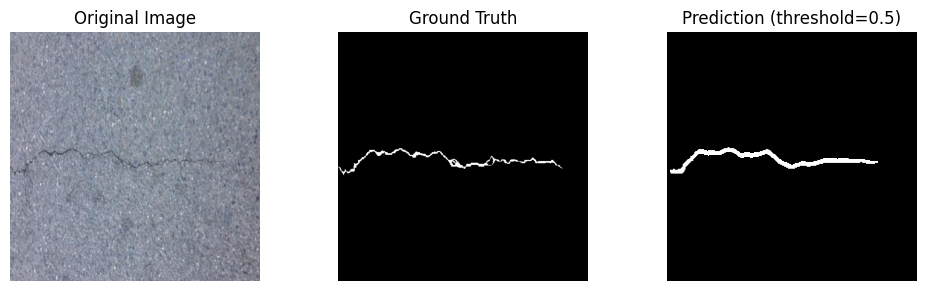

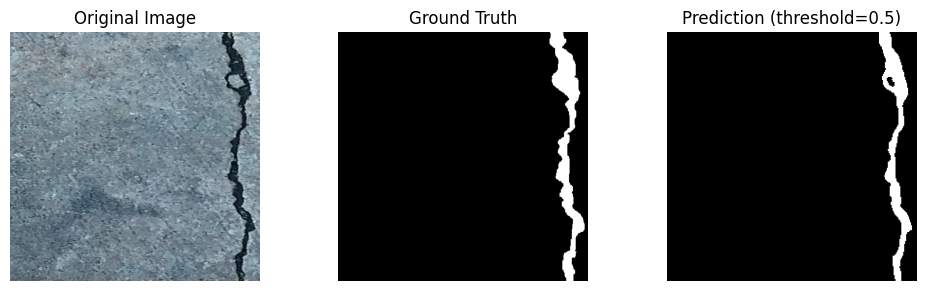

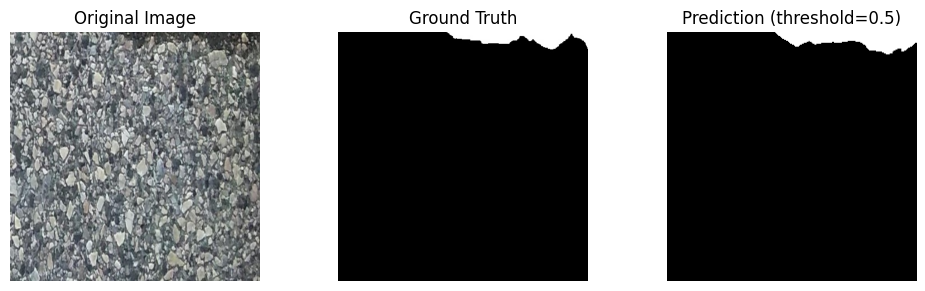

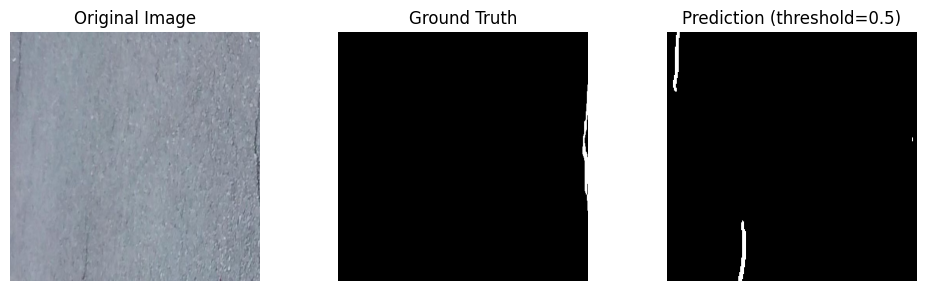

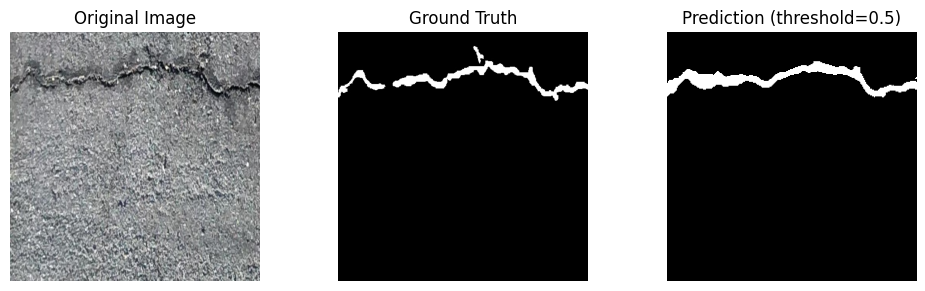

In [14]:
for i in range(10,15):
    display_prediction(
    image_path=list(TEST_IMG_DIR.iterdir())[i],
    model=model,
    device=device,
    transform=val_transform,
    mask_dir="CConCrack/Test/masks",
    threshold=0.5
)

In [15]:
import crack_seg.models.segnet as segnet
model = segnet.get_model().to(DEVICE)
# 2. Load the state dictionary
checkpoint_path = Path(CHECKPOINT_DIR) / f"segnet_best.pth"
state_dict = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(state_dict)
# 3. Set model to evaluation mode (important for inference)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

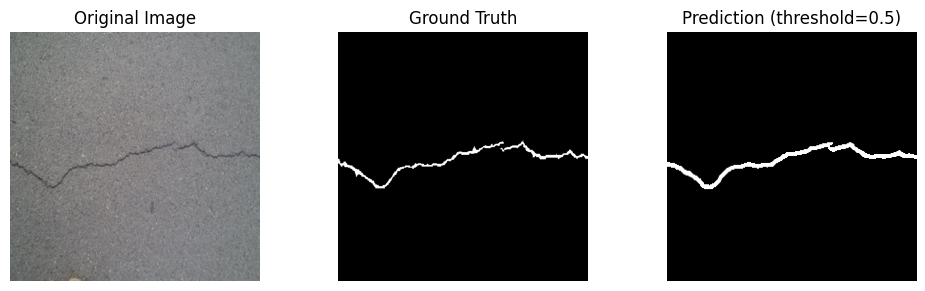

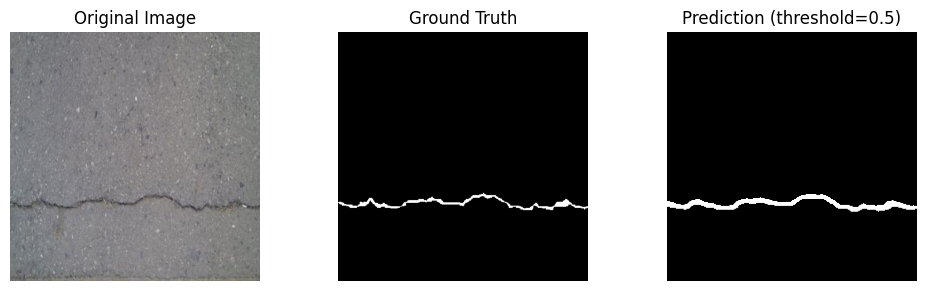

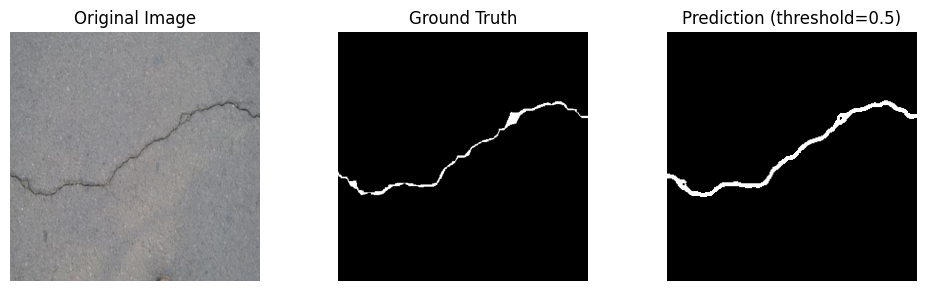

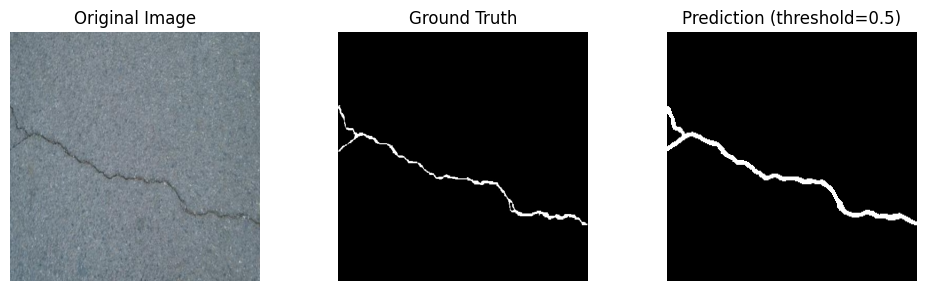

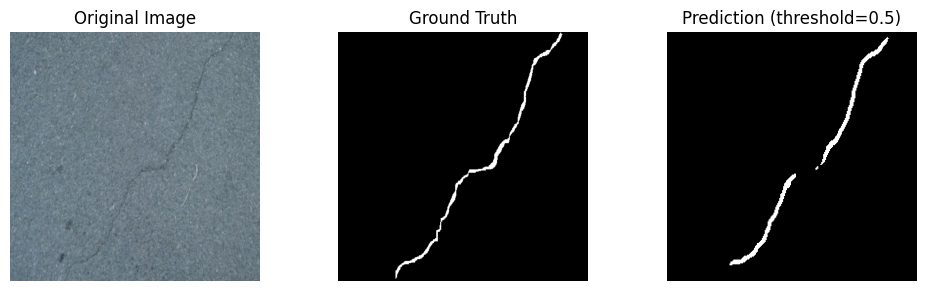

In [16]:
for i in range(5):
    display_prediction(
    image_path=list(TEST_IMG_DIR.iterdir())[i],
    model=model,
    device=device,
    transform=val_transform,
    mask_dir="CConCrack/Test/masks",
    threshold=0.5
)

In [17]:
import crack_seg.models.deeplabv3 as deeplabv3
model = deeplabv3.get_model().to(DEVICE)
# 2. Load the state dictionary
checkpoint_path = Path(CHECKPOINT_DIR) / f"deeplabv3_best.pth"
state_dict = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(state_dict)
# 3. Set model to evaluation mode (important for inference)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

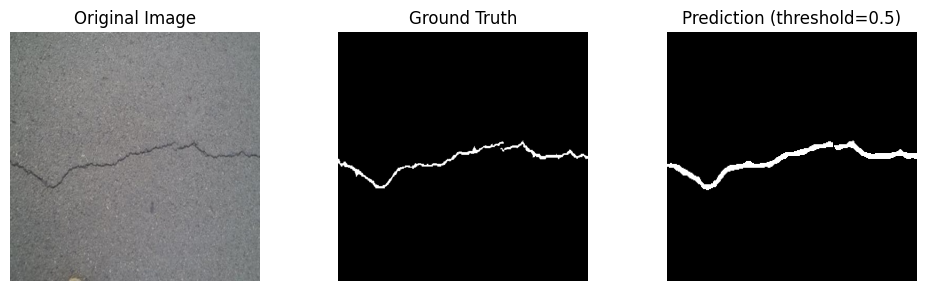

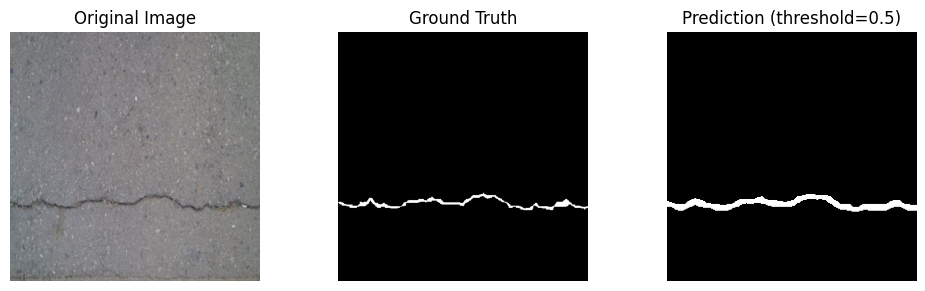

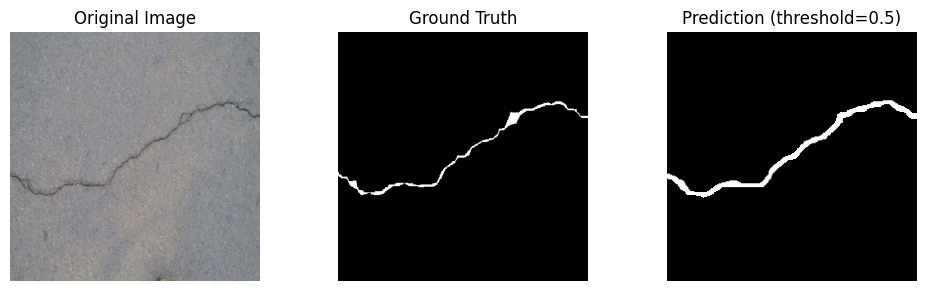

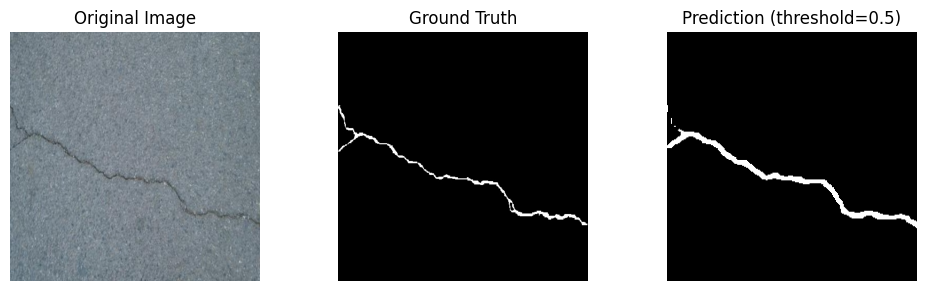

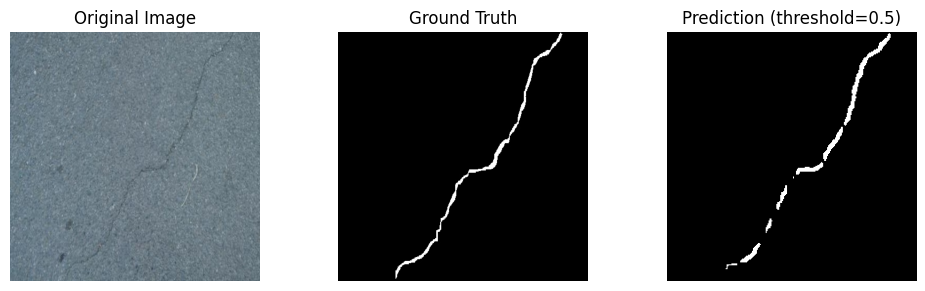

In [18]:
for i in range(5):
    display_prediction(
    image_path=list(TEST_IMG_DIR.iterdir())[i],
    model=model,
    device=device,
    transform=val_transform,
    mask_dir="CConCrack/Test/masks",
    threshold=0.5
)